# BotScan simulation (seed IP only, per-step logging)

In [1]:
import ipaddress, math, random, time, requests
from collections import defaultdict
from dataclasses import dataclass
import pandas as pd, matplotlib.pyplot as plt
import matplotlib.ticker as ticker

AVG_PORTS_PER_IP   = 15                       # changed: 10 ports per IP
COST_PER_SEGMENT   = 256 * AVG_PORTS_PER_IP   # 2,560 IP:port per /24
MAX_BUDGET         = 1_000_000                # 1M IP:port budget
W1, W2             = 10.0, 100.0              # BotScan weights

# Two parameter sets from the paper
PARAMS = {
    'BotScan (K=3, \u03bb=1.0)': {'K': 10, 'lam': 2.0}, #tuned
    'BotScan (K=1, \u03bb=2.0)': {'K': 15, 'lam': 1.0}, #untuned
}


In [2]:
def ip_to_subnet(ip_str):
    ip = ipaddress.ip_address(ip_str)
    return str(ipaddress.ip_network(f"{ip}/24", strict=False))

def fetch_asn(ip, timeout=6):
    headers = {"User-Agent": "Mozilla/5.0 BotScan"}
    try:
        r = requests.get(f"https://ip2asn.ipinfo.app/lookup/{ip}", timeout=timeout, headers=headers)
        if r.ok:
            js = r.json()
            if js.get("announcedBy"):
                return str(js["announcedBy"][0]["asn"])
    except Exception:
        pass
    try:
        r = requests.get(f"https://ipquery.io/api/{ip}", timeout=timeout, headers=headers)
        if r.ok:
            js = r.json()
            if "asn" in js:
                return str(js["asn"]).replace("AS", "")
    except Exception:
        pass
    o1, o2, *_ = ip.split('.')
    return f"AS_{o1}_{o2}"  # offline fallback bucket


In [3]:
with open("seeds.txt") as f:
    seed_rows = [line.strip().split() for line in f if line.strip()]
seeds = [{"ip": ip, "status": status.upper()} for ip, status in seed_rows]

with open("ips.txt") as f:
    discovered_ips = [line.strip() for line in f if line.strip()]

all_ips = {s["ip"] for s in seeds} | set(discovered_ips)

ip_asn = {}
for ip in all_ips:
    ip_asn[ip] = fetch_asn(ip)
    time.sleep(0.2)


In [4]:
from collections import defaultdict
SEED_COUNT = defaultdict(int)
for row in seeds:
    SEED_COUNT[ip_to_subnet(row['ip'])] += 1


In [5]:
def fetch_as_prefixes(asn, timeout=8):
    headers = {"User-Agent": "Mozilla/5.0 BotScan"}
    urls = [
        f"https://bgp.tools/api/as/AS{asn}",
        f"https://api.bgpview.io/asn/{asn}/prefixes",
        f"https://stat.ripe.net/data/announced-prefixes/data.json?resource=AS{asn}",
    ]
    for url in urls:
        try:
            r = requests.get(url, timeout=timeout, headers=headers)
            r.raise_for_status()
            js = r.json()
            if "prefixes" in js:
                prefs = js.get("prefixes", [])
            elif "data" in js and "ipv4_prefixes" in js["data"]:
                prefs = [p["prefix"] for p in js["data"]["ipv4_prefixes"]]
            elif "data" in js and "prefixes" in js["data"]:
                prefs = [p["prefix"] for p in js["data"]["prefixes"]]
            else:
                continue
            prefs24 = [p for p in prefs if str(p).endswith("/24")]
            if prefs24:
                return prefs24
        except Exception:
            continue
    return []

asn_prefixes = {}
for asn in sorted(set(ip_asn.values())):
    prefs = fetch_as_prefixes(asn)
    if not prefs:
        print(f"Offline fallback for AS{asn}: using evidence-only subnets.")
    asn_prefixes[asn] = prefs
    time.sleep(0.2)


Offline fallback for AS63737: using evidence-only subnets.


In [6]:
evidence_subnets = {ip_to_subnet(ip) for ip in discovered_ips}
evidence_subnets.update(ip_to_subnet(s["ip"]) for s in seeds)

candidate_subnets = set()
for prefs in asn_prefixes.values():
    candidate_subnets.update(prefs)
candidate_subnets.update(evidence_subnets)

ground_truth_pool = defaultdict(list)
for ip in discovered_ips:
    ground_truth_pool[ip_to_subnet(ip)].append(ip)


In [7]:
def build_graph(candidate_subnets, evidence_subnets):
    subnet_asn = {}
    for sn in candidate_subnets:
        owner = next((asn for asn, prefs in asn_prefixes.items() if sn in prefs), None)
        if owner is None:
            owner = next((ip_asn[ip] for ip in ip_asn if ip_to_subnet(ip) == sn), None)
        if owner:
            subnet_asn[sn] = owner
    for sn in evidence_subnets:
        if sn not in subnet_asn:
            owner = next((ip_asn[ip] for ip in ip_asn if ip_to_subnet(ip) == sn), None)
            if owner:
                subnet_asn[sn] = owner
    as_to_segs = defaultdict(list)
    for sn, asn in subnet_asn.items():
        as_to_segs[asn].append(sn)
    # adjacency: alphabetical (string) order within each AS
    for asn in as_to_segs:
        as_to_segs[asn] = sorted(as_to_segs[asn])
    seg_pos = {}
    for asn, segs in as_to_segs.items():
        for i, s in enumerate(segs):
            seg_pos[s] = (i, segs)
    return subnet_asn, as_to_segs, seg_pos

subnet_asn, AS_TO_SEGS, SEG_POS = build_graph(candidate_subnets, evidence_subnets)
ALL_SEGMENTS = list(subnet_asn.keys())
print('Total segments', len(ALL_SEGMENTS))


Total segments 4840


In [8]:
@dataclass
class ProbeResult:
    segment: str
    c2s_found: list
    cost: int
    already_probed: bool = False

class Oracle:
    def __init__(self):
        self._log = []
        self._probed = set()
    def probe(self, segment):
        if segment in self._probed:
            prior = next(r for r in self._log if r.segment == segment)
            return ProbeResult(segment, prior.c2s_found, 0, True)
        c2s = list(ground_truth_pool.get(segment, []))
        res = ProbeResult(segment, c2s, COST_PER_SEGMENT)
        self._log.append(res); self._probed.add(segment)
        return res
    @property
    def total_cost(self):
        return sum(r.cost for r in self._log)
    @property
    def n_c2s(self):
        seen=set(); [seen.add(ip) for r in self._log for ip in r.c2s_found]; return len(seen)
    def curve_point(self):
        return (self.total_cost, self.n_c2s)

class ScoreBoard:
    def __init__(self, all_segs, seed_ips, K, lam):
        self.K, self.lam = K, lam
        self.rint = {s:0.0 for s in all_segs}   # local reputation
        self.rext = {s:0.0 for s in all_segs}   # accumulated neighbor influence
        self._probed = set()
    def _propagate(self, seg, delta_rint, sign):
        if self.K == 0 or seg not in SEG_POS: return
        idx, segs = SEG_POS[seg]
        for j in range(1, self.K+1):
            contribution = sign * delta_rint / (self.lam ** j) / (2*self.K)
            for ni in (idx-j, idx+j):
                if 0 <= ni < len(segs):
                    nbr = segs[ni]
                    if nbr not in self._probed:
                        self.rext[nbr] += contribution
    def apply_seed(self, seg, detections, seeds_in_seg):
        old_rint = self.rint.get(seg,0.0)
        self._propagate(seg, old_rint, -1)
        silent = max(0, seeds_in_seg - detections)
        new_rint = W2 * detections + W1 * silent
        self.rint[seg] = new_rint
        self._propagate(seg, new_rint, +1)
    def record_probe(self, seg, n_c2s, seeds_in_seg=0):
        self._probed.add(seg)
        old_rint = self.rint.get(seg,0.0)
        self._propagate(seg, old_rint, -1)
        silent   = max(0, seeds_in_seg - n_c2s)
        new_rint = W2 * n_c2s + W1 * silent
        self.rint[seg] = new_rint
        self._propagate(seg, new_rint, +1)
    def top(self):
        return max((s for s in self.rint if s not in self._probed), key=lambda s: self.score_of(s))
    def score_of(self, seg):
        return self.rint.get(seg,0.0) + self.rext.get(seg,0.0)


In [9]:
LOG = []


In [10]:
DETECTED_C2 = set()


In [11]:
def probe_seed_ips(seed_entries, scoreboard):
    global LOG
    seg_counts = defaultdict(lambda: {'seeds':0, 'live':0})
    for row in seed_entries:
        seg = ip_to_subnet(row['ip'])
        seg_counts[seg]['seeds'] += 1
        if row['status'] == 'L':
            seg_counts[seg]['live'] += 1
    total_cost = 0
    for seg, info in seg_counts.items():
        detections = info['live']
        seeds_here = info['seeds']
        total_cost += seeds_here * AVG_PORTS_PER_IP  # seed IPs only
        scoreboard.apply_seed(seg, detections, seeds_here)
        score_after = scoreboard.score_of(seg)
        LOG.append({'kind':'seed','segment':seg,'score_after':score_after,
                    'detections':detections,'cost':total_cost})
        print(f"Seed IP probes -> {seg} | score={score_after:.4f} | detections={detections}")
    return total_cost


In [12]:
def run_botscan(seed_entries, all_segs, budget=MAX_BUDGET,
                K=3, lam=1.0, r_explore=0.0, random_seed=42):
    """
    Runs BotScan adaptive probing.
    Returns curve: list of (cumulative_cost, cumulative_c2s).
    Fully self-contained — no shared globals for detections.
    """
    detected = set()   # local to this run — no global state
    log_entries = []
    oracle = Oracle()
    sb     = ScoreBoard(all_segs, [s['ip'] for s in seed_entries], K=K, lam=lam)
    rng    = random.Random(random_seed)
    curve  = []

    # ── Phase 1: seed IP probing ──────────────────────────────────────────
    seg_counts = defaultdict(lambda: {'seeds': 0, 'live': 0})
    for row in seed_entries:
        seg = ip_to_subnet(row['ip'])
        seg_counts[seg]['seeds'] += 1
        if row['status'] == 'L':
            seg_counts[seg]['live'] += 1

    seed_cost = 0
    for seg, info in seg_counts.items():
        detections = info['live']          # L seeds = live C2 detections
        seeds_here = info['seeds']
        seed_cost += seeds_here * AVG_PORTS_PER_IP   # cost: seed IPs only
        # Update detected set with any live seed IPs in ground truth
        for ip in ground_truth_pool.get(seg, []):
            if any(s['ip'] == ip and s['status'] == 'L' for s in seed_entries):
                detected.add(ip)
        sb.apply_seed(seg, detections, seeds_here)
        log_entries.append({'kind': 'seed', 'segment': seg,
                             'score_after': sb.score_of(seg),
                             'detections': detections, 'cost': seed_cost})

    curve.append((seed_cost, len(detected)))

    # ── Phase 2: adaptive probing loop ───────────────────────────────────
    unexplored = list(all_segs)     # fresh copy each run
    step = 0
    total_cost = seed_cost

    while unexplored and total_cost < budget:
        chosen       = rng.choice(unexplored) if rng.random() < r_explore else sb.top()
        score_before = sb.score_of(chosen)
        res          = oracle.probe(chosen)
        total_cost  += res.cost
        detected.update(res.c2s_found)
        seeds_here   = SEED_COUNT.get(chosen, 0)
        sb.record_probe(chosen, len(res.c2s_found), seeds_in_seg=seeds_here)
        curve.append((total_cost, len(detected)))
        unexplored.remove(chosen)
        log_entries.append({
            'kind': 'probe', 'step': step, 'segment': chosen,
            'score_before': score_before, 'score_after': sb.score_of(chosen),
            'detections': len(res.c2s_found), 'cum_c2': len(detected),
            'cost': total_cost
        })
        step += 1

    return curve, log_entries


# ── Run both BotScan parameter sets and save curves ───────────────────────────
bs_curves  = {}   # label -> curve
bs_logs    = {}   # label -> log

for label, p in PARAMS.items():
    print(f"\n{'='*60}")
    print(f"Running {label}  (K={p['K']}, lam={p['lam']})")
    print(f"{'='*60}")
    c, l = run_botscan(seeds, ALL_SEGMENTS, budget=MAX_BUDGET,
                       K=p['K'], lam=p['lam'], r_explore=0.0)
    bs_curves[label] = c
    bs_logs[label]   = l
    print(f"  -> {c[-1][1]} C2s detected @ cost {c[-1][0]:,}")

# Keep LOG pointing to K=3 run for backwards compatibility with later cells
LOG          = bs_logs['BotScan (K=3, \u03bb=1.0)']
curve        = bs_curves['BotScan (K=3, \u03bb=1.0)']
DETECTED_C2  = set()  # kept for any downstream cells that check it



Running BotScan (K=3, λ=1.0)  (K=10, lam=2.0)
  -> 37 C2s detected @ cost 1,002,405

Running BotScan (K=1, λ=2.0)  (K=15, lam=1.0)
  -> 37 C2s detected @ cost 1,002,405


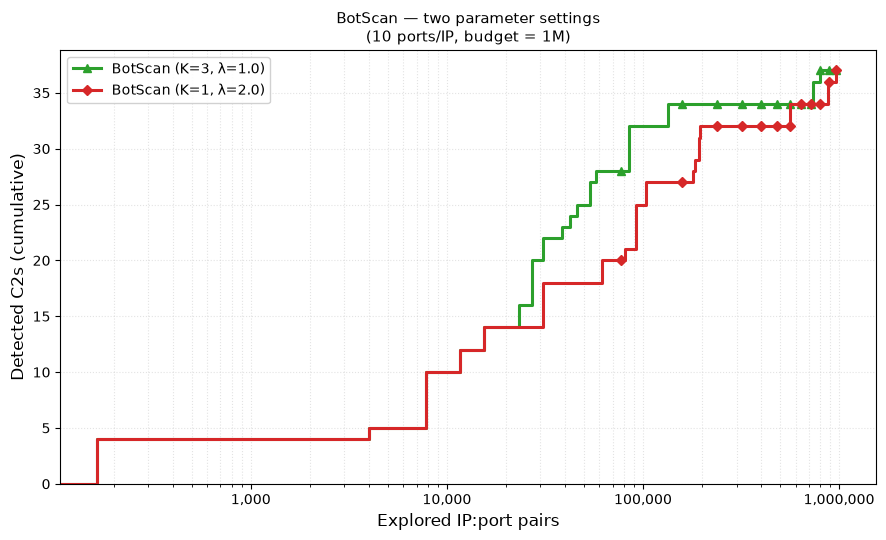

Saved: botscan_two_params.png
  BotScan (K=3, λ=1.0): 37 C2s @ 1,002,405 IP:ports
  BotScan (K=1, λ=2.0): 37 C2s @ 1,002,405 IP:ports


In [13]:
# ── Plot both BotScan parameter variants ────────────────────────────────
BS_STYLES = {
    'BotScan (K=3, \u03bb=1.0)': dict(color='#2ca02c', ls='-',  lw=2.2, marker='^', ms=6),
    'BotScan (K=1, \u03bb=2.0)': dict(color='#d62728', ls='-',  lw=2.2, marker='D', ms=5),
}

fig, ax = plt.subplots(figsize=(9, 5.5))
for label, c in bs_curves.items():
    xs = [0] + [cost for cost, _ in c]
    ys = [0] + [n    for _, n    in c]
    ax.step(xs, ys, where='post', label=label,
            markevery=max(1, len(xs)//12), **BS_STYLES[label])

ax.set_xlabel('Explored IP:port pairs', fontsize=12)
ax.set_ylabel('Detected C2s (cumulative)', fontsize=12)
ax.set_title('BotScan — two parameter settings\n(10 ports/IP, budget = 1M)', fontsize=11)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)
ax.grid(True, which='both', ls=':', alpha=0.35)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('botscan_two_params.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: botscan_two_params.png')

# Print summary
for label, c in bs_curves.items():
    print(f"  {label}: {c[-1][1]} C2s @ {c[-1][0]:,} IP:ports")


In [14]:
log_df = pd.DataFrame(LOG)
display(log_df.head(40))
print('Total logged events', len(log_df))


,kind,segment,score_after,detections,cost,step,score_before,cum_c2
0,seed,94.156.152.0/24,10.000000,0,15,NaN,NaN,NaN
1,seed,94.154.35.0/24,10.000000,0,30,NaN,NaN,NaN
2,seed,45.84.222.0/24,10.000000,0,45,NaN,NaN,NaN
3,seed,45.153.34.0/24,100.000000,1,60,NaN,NaN,NaN
4,seed,103.183.119.0/24,10.000000,0,75,NaN,NaN,NaN
5,seed,154.216.20.0/24,10.000000,0,90,NaN,NaN,NaN
6,seed,176.65.139.0/24,100.000000,1,105,NaN,NaN,NaN
7,seed,95.214.27.0/24,10.000000,0,120,NaN,NaN,NaN
8,seed,154.216.18.0/24,100.125000,1,135,NaN,NaN,NaN
9,seed,95.214.25.0/24,10.000000,0,150,NaN,NaN,NaN


Total logged events 272


In [15]:
from collections import defaultdict

# Load ips.txt and group by /24
ips = [line.strip() for line in open("ips.txt") if line.strip()]
ips_by_seg = defaultdict(list)
for ip in ips:
    ips_by_seg[ip_to_subnet(ip)].append(ip)

# Pull probe results from LOG (list of dicts)
probed = {}  # seg -> detections found in that probe
for ev in LOG:
    if ev.get("kind") == "probe":
        probed[ev["segment"]] = ev.get("detections", 0)

# Any IP in a segment never probed, or probed with 0 detections, is undetected
undetected_ips = []
for seg, seg_ips in ips_by_seg.items():
    if seg not in probed or probed[seg] == 0:
        undetected_ips.extend(seg_ips)

print(f"Total ips.txt entries: {len(ips)}")
print(f"Undetected count: {len(undetected_ips)}")
print("Undetected IPs:")
for ip in undetected_ips:
    print(ip)


Total ips.txt entries: 38
Undetected count: 1
Undetected IPs:
130.12.180.51


## Save BotScan curve data
Both curves saved as CSV for later plotting.

In [16]:
# ── Save both BotScan curves to CSV ─────────────────────────────────────
import csv, os

def save_curve_csv(curve, filename):
    with open(filename, 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['cumulative_cost', 'cumulative_c2s'])
        w.writerows(curve)
    print(f'Saved {filename}  ({len(curve)} points)')

for label, c in bs_curves.items():
    fname = label.replace(' ', '_').replace('(','').replace(')','') \
                  .replace('=','').replace(',','').replace('.','') \
                  .replace('\u03bb','lam') + '.csv'
    save_curve_csv(c, fname)

# Also save as a single combined CSV
rows = {}
for label, c in bs_curves.items():
    for cost, n in c:
        rows.setdefault(cost, {})[label] = n

"""
with open('botscan_curves_combined.csv', 'w', newline='') as f:
    w = csv.writer(f)
    labels = list(bs_curves.keys())
    w.writerow(['cumulative_cost'] + labels)
    for cost in sorted(rows):
        w.writerow([cost] + [rows[cost].get(l, '') for l in labels])
print('Saved botscan_curves_combined.csv')
"""


Saved BotScan_K3_lam10.csv  (262 points)
Saved BotScan_K1_lam20.csv  (262 points)


"\nwith open('botscan_curves_combined.csv', 'w', newline='') as f:\n    w = csv.writer(f)\n    labels = list(bs_curves.keys())\n    w.writerow(['cumulative_cost'] + labels)\n    for cost in sorted(rows):\n        w.writerow([cost] + [rows[cost].get(l, '') for l in labels])\nprint('Saved botscan_curves_combined.csv')\n"

## Baseline 1 — Seeds first, then fully random
Probe every seed /24 first (same seed cost as BotScan), then probe all remaining segments in **uniformly random** order until budget.

Running Baseline 1 (seeds first, then random)...
  -> 11 C2s @ 1,002,405 IP:ports


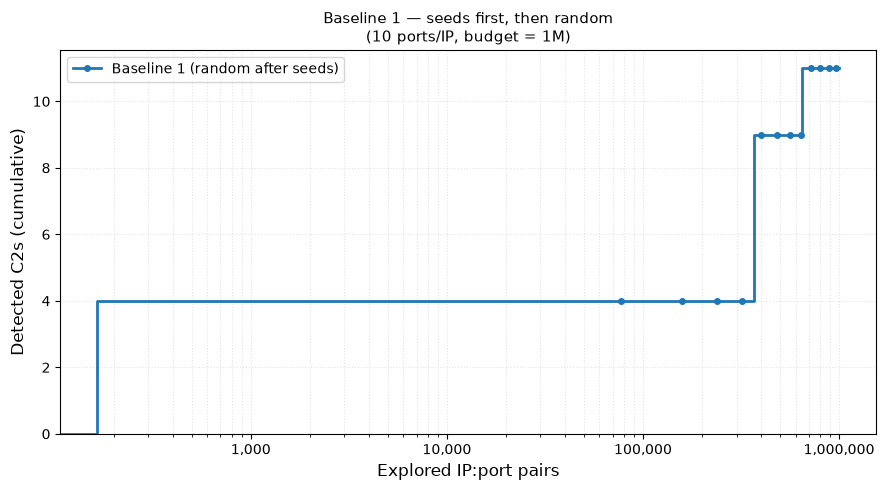

Saved: baseline1.png


In [17]:
def run_baseline1(seed_entries, all_segs, budget=MAX_BUDGET, random_seed=42):
    """
    Baseline 1: probe seed /24s first (no scoring), then random order.
    Same seed-phase cost model as BotScan (seed IPs × AVG_PORTS_PER_IP).
    """
    detected   = set()
    oracle     = Oracle()
    rng        = random.Random(random_seed)
    curve      = []

    # ── Seed phase: count cost by seed IPs, note detections ──────────────
    seg_counts = defaultdict(lambda: {'seeds': 0, 'live': 0})
    for row in seed_entries:
        seg = ip_to_subnet(row['ip'])
        seg_counts[seg]['seeds'] += 1
        if row['status'] == 'L':
            seg_counts[seg]['live'] += 1

    seed_cost  = 0
    seed_segs  = set()
    for seg, info in seg_counts.items():
        seed_cost += info['seeds'] * AVG_PORTS_PER_IP
        if info['live'] > 0:
            for ip in ground_truth_pool.get(seg, []):
                if any(s['ip'] == ip and s['status'] == 'L' for s in seed_entries):
                    detected.add(ip)
        seed_segs.add(seg)

    curve.append((seed_cost, len(detected)))

    # ── Random phase: all segments (including seed segs) in random order ─
    remaining = list(all_segs)
    total_cost = seed_cost

    while total_cost < budget and remaining:
        seg = rng.choice(remaining)   # uniform pick
        remaining.remove(seg)

        res = oracle.probe(seg)
        total_cost += res.cost
        detected.update(res.c2s_found)
        curve.append((total_cost, len(detected)))

    return curve


print('Running Baseline 1 (seeds first, then random)...')
curve_b1 = run_baseline1(seeds, ALL_SEGMENTS, budget=MAX_BUDGET)
print(f'  -> {curve_b1[-1][1]} C2s @ {curve_b1[-1][0]:,} IP:ports')

# Plot Baseline 1
xs_b1 = [0] + [c for c,_ in curve_b1]
ys_b1 = [0] + [n for _,n in curve_b1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.step(xs_b1, ys_b1, where='post', color='#1f77b4', lw=2, marker='o', ms=4,
        markevery=max(1, len(xs_b1)//12), label='Baseline 1 (random after seeds)')
ax.set_xlabel('Explored IP:port pairs', fontsize=12)
ax.set_ylabel('Detected C2s (cumulative)', fontsize=12)
ax.set_title('Baseline 1 — seeds first, then random\n(10 ports/IP, budget = 1M)', fontsize=11)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, which='both', ls=':', alpha=0.35)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('baseline1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: baseline1.png')


## Baseline 2 — Seeds first, then seed-neighborhood /24s, then random
After the seed phase, probe the full /24 of every seed segment first (intra-segment locality). Then probe all remaining in random order.

Running Baseline 2 (seeds → seed /24s → random)...
{'176.65.139.34', '154.216.18.243', '176.65.132.198', '95.214.27.155', '176.65.139.20', '45.153.34.92', '94.154.35.154', '176.65.139.35', '176.65.132.197', '154.216.20.139', '176.65.132.27', '154.216.20.108', '176.65.132.153', '154.216.18.131', '176.65.132.194', '45.84.222.176', '95.214.25.82', '95.214.27.202', '176.65.132.246', '154.216.18.245', '45.153.34.187'} 21
  -> 21 C2s @ 1,002,405 IP:ports


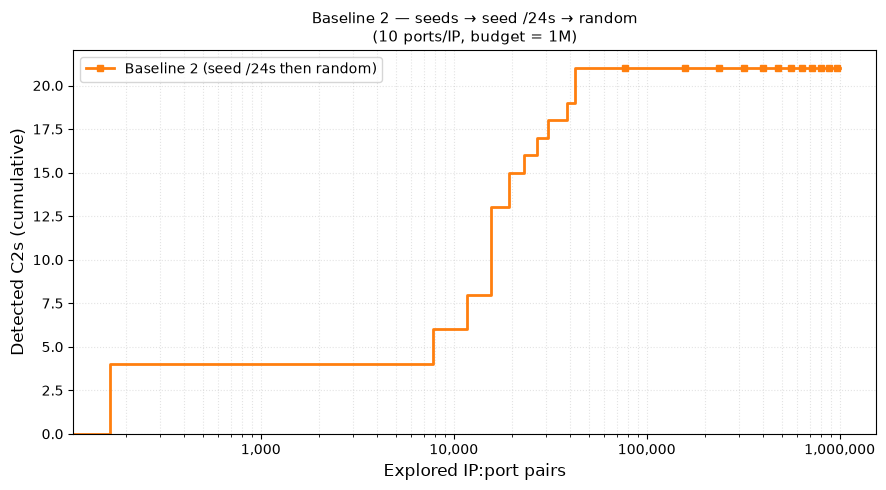

Saved: baseline2.png


In [18]:
def run_baseline2(seed_entries, all_segs, budget=MAX_BUDGET, random_seed=42):
    """
    Baseline 2: probe seed /24s first, then full /24 scan of seed segments,
    then remaining in random order.
    Phase 1 — seed cost: seed IPs × AVG_PORTS_PER_IP (status known)
    Phase 2 — full segment probe of every /24 containing a seed (256 × ports)
    Phase 3 — remaining segments in random order
    """
    detected   = set()
    oracle     = Oracle()
    rng        = random.Random(random_seed)
    curve      = []

    # ── Phase 1: seed status (same cost model) ────────────────────────────
    seg_counts = defaultdict(lambda: {'seeds': 0, 'live': 0})
    for row in seed_entries:
        seg = ip_to_subnet(row['ip'])
        seg_counts[seg]['seeds'] += 1
        if row['status'] == 'L':
            seg_counts[seg]['live'] += 1

    seed_cost = 0
    seed_segs = set()
    for seg, info in seg_counts.items():
        seed_cost += info['seeds'] * AVG_PORTS_PER_IP
        if info['live'] > 0:
            for ip in ground_truth_pool.get(seg, []):
                if any(s['ip'] == ip and s['status'] == 'L' for s in seed_entries):
                    detected.add(ip)
        seed_segs.add(seg)

    curve.append((seed_cost, len(detected)))
    total_cost = seed_cost

    # ── Phase 2: full /24 probe of every seed segment ─────────────────────
    probed = set()
    for seg in sorted(seed_segs):
        if total_cost >= budget:
            break
        res = oracle.probe(seg)
        total_cost += res.cost
        detected.update(res.c2s_found)
        probed.add(seg)
        curve.append((total_cost, len(detected)))
    print(detected, len(detected))
    # ── Phase 3: remaining segments in random order ───────────────────────
    remaining = list(set(all_segs) - set(probed))

    while total_cost < budget and remaining:
        seg = rng.choice(remaining)   # uniform pick
        remaining.remove(seg)

        res = oracle.probe(seg)
        total_cost += res.cost
        detected.update(res.c2s_found)
        curve.append((total_cost, len(detected)))

    return curve


print('Running Baseline 2 (seeds → seed /24s → random)...')
curve_b2 = run_baseline2(seeds, ALL_SEGMENTS, budget=MAX_BUDGET)
print(f'  -> {curve_b2[-1][1]} C2s @ {curve_b2[-1][0]:,} IP:ports')

# Plot Baseline 2
xs_b2 = [0] + [c for c,_ in curve_b2]
ys_b2 = [0] + [n for _,n in curve_b2]
fig, ax = plt.subplots(figsize=(9, 5))
ax.step(xs_b2, ys_b2, where='post', color='#ff7f0e', lw=2, marker='s', ms=4,
        markevery=max(1, len(xs_b2)//12), label='Baseline 2 (seed /24s then random)')
ax.set_xlabel('Explored IP:port pairs', fontsize=12)
ax.set_ylabel('Detected C2s (cumulative)', fontsize=12)
ax.set_title('Baseline 2 — seeds → seed /24s → random\n(10 ports/IP, budget = 1M)', fontsize=11)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, which='both', ls=':', alpha=0.35)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('baseline2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: baseline2.png')


## Combined Plot — All Four Methods
BotScan (K=3 λ=1), BotScan (K=1 λ=2), Baseline 1, Baseline 2 on one figure.

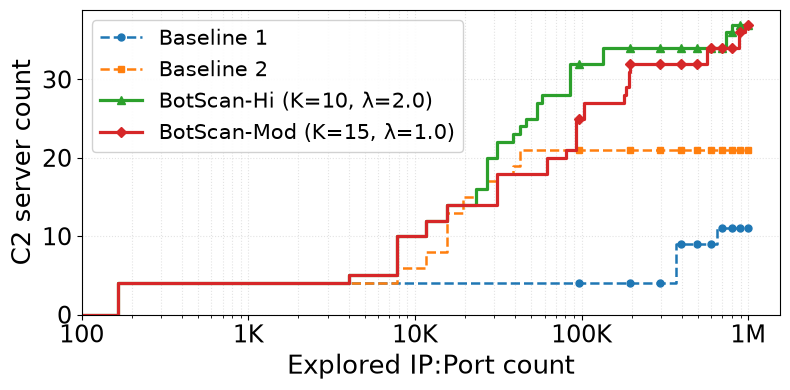

Saved: botscan_all_methods.png

Method                          Final C2s   Final cost
--------------------------------------------------------
Baseline 1                             11    1,002,405
Baseline 2                             21    1,002,405
BotScan-Hi (K=10, λ=2.0)               37    1,002,405
BotScan-Mod (K=15, λ=1.0)              37    1,002,405


In [19]:
# ── Combined plot: all 4 methods ────────────────────────────────────────
import matplotlib.ticker as ticker

all_curves = {
    'Baseline 1':     (curve_b1, dict(color='#1f77b4', ls='--', lw=1.8, marker='o', ms=5)),
    'Baseline 2':  (curve_b2, dict(color='#ff7f0e', ls='--', lw=1.8, marker='s', ms=5)),
    'BotScan-Hi (K=10, \u03bb=2.0)': (bs_curves['BotScan (K=3, \u03bb=1.0)'],
                                   dict(color='#2ca02c', ls='-',  lw=2.3, marker='^', ms=6)),
    'BotScan-Mod (K=15, \u03bb=1.0)': (bs_curves['BotScan (K=1, \u03bb=2.0)'],
                                   dict(color='#d62728', ls='-',  lw=2.3, marker='D', ms=5)),
}

fig, ax = plt.subplots(figsize=(8, 4))          # height reduced: 6 → 4

for label, (c, style) in all_curves.items():
    xs = [0] + [cost for cost, _ in c]
    ys = [0] + [n    for _, n    in c]
    ax.step(xs, ys, where='post', label=label,
            markevery=max(1, len(xs)//10), **style)

ax.set_xlabel('Explored IP:Port count', fontsize=19)
ax.set_ylabel('C2 server count',        fontsize=19)
ax.tick_params(axis='both', labelsize=17)

ax.set_xscale('log')

# ── K / M formatter ───────────────────────────────────────────────────────
def fmt_k(x, pos):
    if x >= 1_000_000:
        v = x / 1_000_000
        return f'{v:.0f}M' if v == int(v) else f'{v:.1f}M'
    if x >= 1_000:
        v = x / 1_000
        return f'{v:.0f}K' if v == int(v) else f'{v:.1f}K'
    return f'{int(x)}'

ax.xaxis.set_major_formatter(ticker.FuncFormatter(fmt_k))

# ── ticks: 100 as start marker + clean decades ───────────────────────────
ax.set_xticks([100, 1_000, 10_000, 100_000, 1_000_000])

# ── y-axis: tighter spacing (step of 10 instead of default ~5–8) ─────────
ax.yaxis.set_major_locator(ticker.MultipleLocator(10))

ax.legend(fontsize=15, loc='upper left', framealpha=0.9)
ax.grid(True, which='both', ls=':', alpha=0.35)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('botscan_all_methods.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: botscan_all_methods.png')

# Quick summary table
print(f"\n{'Method':<30} {'Final C2s':>10} {'Final cost':>12}")
print('-' * 56)
for label, (c, _) in all_curves.items():
    print(f"{label:<30} {c[-1][1]:>10} {c[-1][0]:>12,}")

## Data Points at Specific IP:Port Budgets
Interpolate cumulative C2 count at exactly the requested x-axis values.

In [20]:
# ── Data points at requested IP:port budgets ────────────────────────────
X_POINTS = [
    1200, 2560, 5120, 7680, 10240, 12800, 15360, 17920, 20480, 23040,
    25600, 28160, 30720, 33280, 35840, 38400, 81920, 179200, 424960,
    670720, 737280, 817280, 1000000
]

def c2s_at(curve, target):
    """Return cumulative C2s found at the largest cost <= target."""
    best = 0
    for cost, n in curve:
        if cost <= target:
            best = n
    return best

# Build table
col_curves = {
    'Baseline_1':    curve_b1,
    'Baseline_2':    curve_b2,
    'BotScan_K3L1':  bs_curves['BotScan (K=3, \u03bb=1.0)'],
    'BotScan_K1L2':  bs_curves['BotScan (K=1, \u03bb=2.0)'],
}

rows = []
for x in X_POINTS:
    row = {'ip_port_budget': x}
    for name, c in col_curves.items():
        row[name] = c2s_at(c, x)
    rows.append(row)

df_pts = pd.DataFrame(rows)
df_pts = df_pts.set_index('ip_port_budget')

print('Cumulative C2s detected at each IP:port budget checkpoint')
print('=' * 70)
print(df_pts.to_string())

df_pts.to_csv('datapoints_table.csv')
print('\nSaved: datapoints_table.csv')
display(df_pts)


Cumulative C2s detected at each IP:port budget checkpoint
                Baseline_1  Baseline_2  BotScan_K3L1  BotScan_K1L2
ip_port_budget                                                    
1200                     4           4             4             4
2560                     4           4             4             4
5120                     4           4             5             5
7680                     4           4             5             5
10240                    4           6            10            10
12800                    4           8            12            12
15360                    4           8            12            12
17920                    4          13            14            14
20480                    4          15            14            14
23040                    4          15            14            14
25600                    4          16            16            14
28160                    4          17            20            14
3072

,Baseline_1,Baseline_2,BotScan_K3L1,BotScan_K1L2
ip_port_budget,,,,
1200,4,4,4,4
2560,4,4,4,4
5120,4,4,5,5
7680,4,4,5,5
10240,4,6,10,10
12800,4,8,12,12
15360,4,8,12,12
17920,4,13,14,14
20480,4,15,14,14


## Baseline 3 — AS-reputation ranked probing
Rank each AS by **reputation = (# seeds present in the AS) / (# candidate segments in the AS)**.
Explore every candidate segment belonging to the highest-reputation AS first, then the next-highest AS,
and so on (no adaptive scoring/propagation — an AS is exhausted before moving to the next).
Same seed-phase cost model as Baseline 1 / Baseline 2 / BotScan.

Note: this cell only re-runs the graph-building steps (seed/IP loading, ASN + prefix lookups) needed to
compute Baseline 3 — it does **not** re-run or re-save Baseline 1, Baseline 2, or BotScan, so those
existing figures/CSVs are left completely untouched.

In [1]:
# ── Rebuild just the graph-construction state needed for Baseline 3 ──
# (mirrors cells 1,2,3,4,5,6,7,8 above; does not touch LOG/DETECTED_C2/ScoreBoard/BotScan/Baseline1/2)
import ipaddress, time, requests
from collections import defaultdict
from dataclasses import dataclass
import pandas as pd, matplotlib.pyplot as plt
import matplotlib.ticker as ticker

AVG_PORTS_PER_IP   = 15
COST_PER_SEGMENT   = 256 * AVG_PORTS_PER_IP
MAX_BUDGET         = 1_000_000

def ip_to_subnet(ip_str):
    ip = ipaddress.ip_address(ip_str)
    return str(ipaddress.ip_network(f"{ip}/24", strict=False))

def fetch_asn(ip, timeout=6):
    headers = {"User-Agent": "Mozilla/5.0 BotScan"}
    try:
        r = requests.get(f"https://ip2asn.ipinfo.app/lookup/{ip}", timeout=timeout, headers=headers)
        if r.ok:
            js = r.json()
            if js.get("announcedBy"):
                return str(js["announcedBy"][0]["asn"])
    except Exception:
        pass
    try:
        r = requests.get(f"https://ipquery.io/api/{ip}", timeout=timeout, headers=headers)
        if r.ok:
            js = r.json()
            if "asn" in js:
                return str(js["asn"]).replace("AS", "")
    except Exception:
        pass
    o1, o2, *_ = ip.split('.')
    return f"AS_{o1}_{o2}"

with open("seeds.txt") as f:
    seed_rows = [line.strip().split() for line in f if line.strip()]
seeds = [{"ip": ip, "status": status.upper()} for ip, status in seed_rows]

with open("ips.txt") as f:
    discovered_ips = [line.strip() for line in f if line.strip()]

all_ips = {s["ip"] for s in seeds} | set(discovered_ips)

ip_asn = {}
for ip in all_ips:
    ip_asn[ip] = fetch_asn(ip)
    time.sleep(0.1)

def fetch_as_prefixes(asn, timeout=8):
    headers = {"User-Agent": "Mozilla/5.0 BotScan"}
    urls = [
        f"https://bgp.tools/api/as/AS{asn}",
        f"https://api.bgpview.io/asn/{asn}/prefixes",
        f"https://stat.ripe.net/data/announced-prefixes/data.json?resource=AS{asn}",
    ]
    for url in urls:
        try:
            r = requests.get(url, timeout=timeout, headers=headers)
            r.raise_for_status()
            js = r.json()
            if "prefixes" in js:
                prefs = js.get("prefixes", [])
            elif "data" in js and "ipv4_prefixes" in js["data"]:
                prefs = [p["prefix"] for p in js["data"]["ipv4_prefixes"]]
            elif "data" in js and "prefixes" in js["data"]:
                prefs = [p["prefix"] for p in js["data"]["prefixes"]]
            else:
                continue
            prefs24 = [p for p in prefs if str(p).endswith("/24")]
            if prefs24:
                return prefs24
        except Exception:
            continue
    return []

asn_prefixes = {}
for asn in sorted(set(ip_asn.values())):
    prefs = fetch_as_prefixes(asn)
    asn_prefixes[asn] = prefs
    time.sleep(0.1)

evidence_subnets = {ip_to_subnet(ip) for ip in discovered_ips}
evidence_subnets.update(ip_to_subnet(s["ip"]) for s in seeds)

candidate_subnets = set()
for prefs in asn_prefixes.values():
    candidate_subnets.update(prefs)
candidate_subnets.update(evidence_subnets)

ground_truth_pool = defaultdict(list)
for ip in discovered_ips:
    ground_truth_pool[ip_to_subnet(ip)].append(ip)

def build_graph(candidate_subnets, evidence_subnets):
    subnet_asn = {}
    for sn in candidate_subnets:
        owner = next((asn for asn, prefs in asn_prefixes.items() if sn in prefs), None)
        if owner is None:
            owner = next((ip_asn[ip] for ip in ip_asn if ip_to_subnet(ip) == sn), None)
        if owner:
            subnet_asn[sn] = owner
    for sn in evidence_subnets:
        if sn not in subnet_asn:
            owner = next((ip_asn[ip] for ip in ip_asn if ip_to_subnet(ip) == sn), None)
            if owner:
                subnet_asn[sn] = owner
    as_to_segs = defaultdict(list)
    for sn, asn in subnet_asn.items():
        as_to_segs[asn].append(sn)
    for asn in as_to_segs:
        as_to_segs[asn] = sorted(as_to_segs[asn])
    return subnet_asn, as_to_segs

subnet_asn, AS_TO_SEGS = build_graph(candidate_subnets, evidence_subnets)
ALL_SEGMENTS = list(subnet_asn.keys())
print('Total candidate segments (today\'s live AS/prefix snapshot):', len(ALL_SEGMENTS))
print('NOTE: the original evaluation (Baseline 1/2, BotScan figures above) used', 4840,
      'segments from an earlier snapshot; external ASN/prefix lookup services can drift over time,')
print('so this count may differ slightly. Baseline 1/2/BotScan cells above were NOT re-run.')

@dataclass
class ProbeResult:
    segment: str
    c2s_found: list
    cost: int
    already_probed: bool = False

class Oracle:
    def __init__(self):
        self._log = []
        self._probed = set()
    def probe(self, segment):
        if segment in self._probed:
            prior = next(r for r in self._log if r.segment == segment)
            return ProbeResult(segment, prior.c2s_found, 0, True)
        c2s = list(ground_truth_pool.get(segment, []))
        res = ProbeResult(segment, c2s, COST_PER_SEGMENT)
        self._log.append(res); self._probed.add(segment)
        return res


Total candidate segments (today's live AS/prefix snapshot): 4844
NOTE: the original evaluation (Baseline 1/2, BotScan figures above) used 4840 segments from an earlier snapshot; external ASN/prefix lookup services can drift over time,
so this count may differ slightly. Baseline 1/2/BotScan cells above were NOT re-run.


Running Baseline 3 (AS-reputation ranked)...
AS rank ASN         seeds  candidates  reputation
1       63737           1           1      1.0000
2       219502          1           2      0.5000
3       214209          1           4      0.2500
4       197170          2          13      0.1538
5       202412          1          21      0.0476
6       215439          1         137      0.0073
7       20911           1         143      0.0070
8       11404           2        1298      0.0015
9       212238          1        3193      0.0003
10      51396           0          32      0.0000

Exploration visits 10 contiguous AS-blocks covering 10 distinct ASes (exhaustive per-AS blocks confirmed)

  -> 19 C2s @ 1,002,405 IP:ports


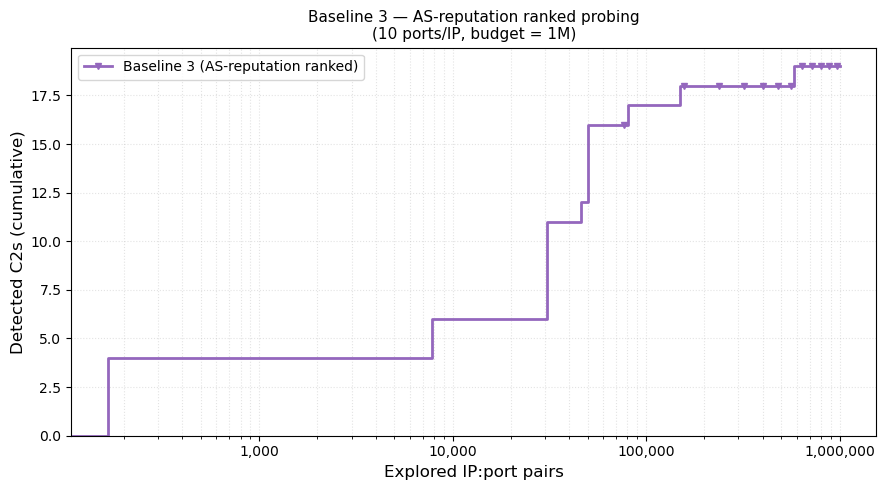

Saved: baseline3.png
Saved Baseline_3_AS_reputation.csv  (262 points)


In [2]:
def run_baseline3(seed_entries, all_segs, budget=MAX_BUDGET, verbose=True):
    """
    Baseline 3: AS-reputation ranked ordering.
    reputation(AS) = (# seeds present in the AS) / (# candidate segments in the AS)
    Explore every candidate segment of the highest-reputation AS first,
    then the next-highest, and so on (no adaptive scoring/propagation).
    Same seed-phase cost model as Baseline 1 / Baseline 2 / BotScan.
    """
    detected   = set()
    oracle     = Oracle()
    curve      = []

    # ── Phase 1: seed IP status (cost + detections) — identical to Baseline 1/2 ──
    seg_counts = defaultdict(lambda: {'seeds': 0, 'live': 0})
    for row in seed_entries:
        seg = ip_to_subnet(row['ip'])
        seg_counts[seg]['seeds'] += 1
        if row['status'] == 'L':
            seg_counts[seg]['live'] += 1

    seed_cost = 0
    for seg, info in seg_counts.items():
        seed_cost += info['seeds'] * AVG_PORTS_PER_IP
        if info['live'] > 0:
            for ip in ground_truth_pool.get(seg, []):
                if any(s['ip'] == ip and s['status'] == 'L' for s in seed_entries):
                    detected.add(ip)

    curve.append((seed_cost, len(detected)))
    total_cost = seed_cost

    # ── Phase 2: rank ASes by reputation = seeds_in_AS / candidates_in_AS ──
    seeds_per_as = defaultdict(int)
    for row in seed_entries:
        seg = ip_to_subnet(row['ip'])
        asn = subnet_asn.get(seg) or ip_asn.get(row['ip'])
        if asn:
            seeds_per_as[asn] += 1

    as_reputation = {
        asn: seeds_per_as.get(asn, 0) / len(segs)
        for asn, segs in AS_TO_SEGS.items() if segs
    }
    ranked_asns = sorted(as_reputation, key=lambda a: (-as_reputation[a], a))

    if verbose:
        print(f"{'AS rank':<8}{'ASN':<10}{'seeds':>7}{'candidates':>12}{'reputation':>12}")
        for rank, asn in enumerate(ranked_asns, 1):
            print(f"{rank:<8}{asn:<10}{seeds_per_as.get(asn,0):>7}{len(AS_TO_SEGS[asn]):>12}{as_reputation[asn]:>12.4f}")

    # ── Explore candidate segments AS-by-AS, highest-reputation AS first ──
    all_segs_set = set(all_segs)
    ordered_segs, seen = [], set()
    as_of_seg = {}
    for asn in ranked_asns:
        for seg in AS_TO_SEGS[asn]:          # already alphabetically sorted
            if seg in all_segs_set and seg not in seen:
                ordered_segs.append(seg)
                seen.add(seg)
                as_of_seg[seg] = asn
    for seg in all_segs:                      # safety net for any leftovers
        if seg not in seen:
            ordered_segs.append(seg)
            seen.add(seg)
            as_of_seg[seg] = subnet_asn.get(seg, '?')

    if verbose:
        # confirm block structure: each AS's segments are explored contiguously
        seen_as_order = []
        for seg in ordered_segs:
            a = as_of_seg[seg]
            if not seen_as_order or seen_as_order[-1] != a:
                seen_as_order.append(a)
        n_blocks = len(seen_as_order)
        n_distinct = len(set(as_of_seg.values()))
        print(f"\nExploration visits {n_blocks} contiguous AS-blocks covering {n_distinct} distinct ASes "
              f"({'exhaustive per-AS blocks confirmed' if n_blocks == n_distinct else 'WARNING: AS blocks are not contiguous!'})")

    for seg in ordered_segs:
        if total_cost >= budget:
            break
        res = oracle.probe(seg)
        total_cost += res.cost
        detected.update(res.c2s_found)
        curve.append((total_cost, len(detected)))

    return curve


print('Running Baseline 3 (AS-reputation ranked)...')
curve_b3 = run_baseline3(seeds, ALL_SEGMENTS, budget=MAX_BUDGET)
print(f'\n  -> {curve_b3[-1][1]} C2s @ {curve_b3[-1][0]:,} IP:ports')

# Plot Baseline 3 on its own figure — brand-new filename, existing PNGs untouched
xs_b3 = [0] + [c for c, _ in curve_b3]
ys_b3 = [0] + [n for _, n in curve_b3]
fig, ax = plt.subplots(figsize=(9, 5))
ax.step(xs_b3, ys_b3, where='post', color='#9467bd', lw=2, marker='v', ms=4,
        markevery=max(1, len(xs_b3)//12), label='Baseline 3 (AS-reputation ranked)')
ax.set_xlabel('Explored IP:port pairs', fontsize=12)
ax.set_ylabel('Detected C2s (cumulative)', fontsize=12)
ax.set_title('Baseline 3 — AS-reputation ranked probing\n(10 ports/IP, budget = 1M)', fontsize=11)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, which='both', ls=':', alpha=0.35)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('baseline3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: baseline3.png')

import csv
with open('Baseline_3_AS_reputation.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['cumulative_cost', 'cumulative_c2s'])
    w.writerows(curve_b3)
print(f'Saved Baseline_3_AS_reputation.csv  ({len(curve_b3)} points)')


## Combined Plot — All Five Methods (adds Baseline 3)
Adds the new Baseline 3 line to the existing four-method comparison **without recomputing
Baseline 1, Baseline 2, or BotScan**: their curves are reloaded exactly as already saved —
`datapoints_table.csv` for Baseline 1 / Baseline 2 (checkpoint resolution) and
`BotScan_K3_lam10.csv` / `BotScan_K1_lam20.csv` for BotScan (full resolution) — so those four
lines are numerically identical to the ones already plotted above. Only Baseline 3 uses freshly
computed data. The original 4-method figure (`botscan_all_methods.png`) and its cell are left
completely untouched; this is saved separately as `botscan_all_methods_with_baseline3.png`.

Because Baseline 1 / Baseline 2 are reloaded at checkpoint resolution (~23 points) rather than
full per-probe resolution (which was never saved to disk), their lines below are visibly steppier
than the smoother curves in the original combined figure — the underlying values are exact, only
the plotting resolution is coarser.

True seed-phase point (shared by Baseline 1/2/BotScan): cost=165, detected=4


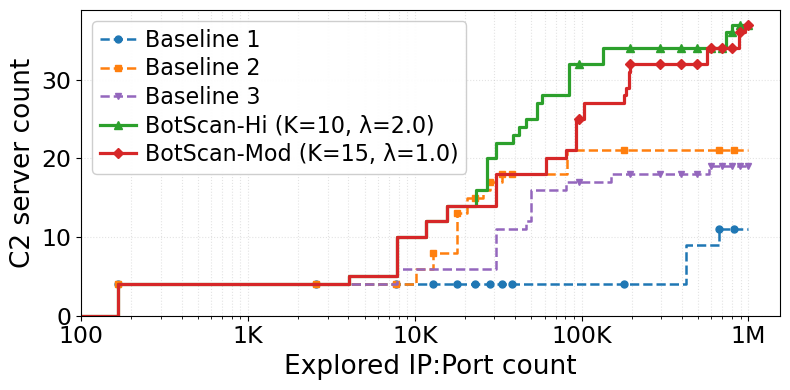

Saved: botscan_all_methods_with_baseline3.png  (original botscan_all_methods.png left untouched)

Method                          Final C2s   Final cost
--------------------------------------------------------
Baseline 1                             11    1,000,000
Baseline 2                             21    1,000,000
Baseline 3                             19    1,002,405
BotScan-Hi (K=10, λ=2.0)               37    1,002,405
BotScan-Mod (K=15, λ=1.0)              37    1,002,405


In [3]:
# ── Combined plot: all 5 methods, reusing EXACT saved data for the 4 existing lines ──
import pandas as pd

_dp = pd.read_csv('datapoints_table.csv')

# The true seed-phase point (cost, detections) is identical across Baseline 1/2/BotScan —
# it depends only on seeds.txt + ips.txt (no network), so we recompute it exactly rather
# than starting the reloaded curves at (0, 0) straight into the first 1200-cost checkpoint
# (which visibly delayed the very first jump compared to the original figure).
def _seed_phase_point():
    seg_counts = defaultdict(lambda: {'seeds': 0, 'live': 0})
    for row in seeds:
        seg = ip_to_subnet(row['ip'])
        seg_counts[seg]['seeds'] += 1
        if row['status'] == 'L':
            seg_counts[seg]['live'] += 1
    detected = set()
    seed_cost = 0
    for seg, info in seg_counts.items():
        seed_cost += info['seeds'] * AVG_PORTS_PER_IP
        if info['live'] > 0:
            for ip in ground_truth_pool.get(seg, []):
                if any(s['ip'] == ip and s['status'] == 'L' for s in seeds):
                    detected.add(ip)
    return seed_cost, len(detected)

_seed_cost, _seed_detected = _seed_phase_point()
print(f'True seed-phase point (shared by Baseline 1/2/BotScan): cost={_seed_cost}, detected={_seed_detected}')

def _checkpoint_curve(col):
    pts = [(0, 0), (_seed_cost, _seed_detected)] + list(zip(_dp['ip_port_budget'], _dp[col]))
    return pts

def _load_curve_csv(fname):
    df = pd.read_csv(fname)
    return list(zip(df['cumulative_cost'], df['cumulative_c2s']))

curve_b1_saved = _checkpoint_curve('Baseline_1')
curve_b2_saved = _checkpoint_curve('Baseline_2')
curve_bsK3_saved = _load_curve_csv('BotScan_K3_lam10.csv')
curve_bsK1_saved = _load_curve_csv('BotScan_K1_lam20.csv')

# Legend order: Baseline 1, Baseline 2, Baseline 3, BotScan-Hi, BotScan-Mod
all_curves_v2 = {
    'Baseline 1':                     (curve_b1_saved,   dict(color='#1f77b4', ls='--', lw=1.8, marker='o', ms=5)),
    'Baseline 2':                     (curve_b2_saved,   dict(color='#ff7f0e', ls='--', lw=1.8, marker='s', ms=5)),
    'Baseline 3':                     (curve_b3,         dict(color='#9467bd', ls='--', lw=1.8, marker='v', ms=5)),
    'BotScan-Hi (K=10, \u03bb=2.0)':  (curve_bsK3_saved, dict(color='#2ca02c', ls='-',  lw=2.3, marker='^', ms=6)),
    'BotScan-Mod (K=15, \u03bb=1.0)': (curve_bsK1_saved, dict(color='#d62728', ls='-',  lw=2.3, marker='D', ms=5)),
}

fig, ax = plt.subplots(figsize=(8, 4))

for label, (c, style) in all_curves_v2.items():
    xs = [0] + [cost for cost, _ in c]
    ys = [0] + [n    for _, n    in c]
    ax.step(xs, ys, where='post', label=label,
            markevery=max(1, len(xs)//10), **style)

def fmt_k(x, pos):
    if x >= 1_000_000:
        v = x / 1_000_000
        return f'{v:.0f}M' if v == int(v) else f'{v:.1f}M'
    if x >= 1_000:
        v = x / 1_000
        return f'{v:.0f}K' if v == int(v) else f'{v:.1f}K'
    return f'{int(x)}'

ax.set_xlabel('Explored IP:Port count', fontsize=19)
ax.set_ylabel('C2 server count',        fontsize=19)
ax.tick_params(axis='both', labelsize=17)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(fmt_k))
ax.set_xticks([100, 1_000, 10_000, 100_000, 1_000_000])
ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
ax.legend(fontsize=16, loc='upper left', framealpha=0.95, labelspacing=0.25, handlelength=1.6, handletextpad=0.4, borderpad=0.35)
ax.grid(True, which='both', ls=':', alpha=0.35)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('botscan_all_methods_with_baseline3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: botscan_all_methods_with_baseline3.png  (original botscan_all_methods.png left untouched)')

print(f"\n{'Method':<30} {'Final C2s':>10} {'Final cost':>12}")
print('-' * 56)
for label, (c, _) in all_curves_v2.items():
    print(f"{label:<30} {c[-1][1]:>10} {c[-1][0]:>12,}")


## Data Points at Specific IP:Port Budgets (with Baseline 3)
Extends the checkpoint table with a `Baseline_3` column, computed at the same `X_POINTS`
checkpoints used originally. Baseline 1 / Baseline 2 / BotScan columns are copied verbatim from
`datapoints_table.csv` (unchanged). Saved separately as `datapoints_table_with_baseline3.csv` —
the original `datapoints_table.csv` is left untouched.

In [4]:
# ── Data points at requested IP:port budgets — now including Baseline 3 ──
X_POINTS = [
    1200, 2560, 5120, 7680, 10240, 12800, 15360, 17920, 20480, 23040,
    25600, 28160, 30720, 33280, 35840, 38400, 81920, 179200, 424960,
    670720, 737280, 817280, 1000000
]

def c2s_at(curve, target):
    best = 0
    for cost, n in curve:
        if cost <= target:
            best = n
    return best

df_pts_v2 = pd.read_csv('datapoints_table.csv').set_index('ip_port_budget')
df_pts_v2['Baseline_3'] = [c2s_at(curve_b3, x) for x in df_pts_v2.index]

print('Cumulative C2s detected at each IP:port budget checkpoint (with Baseline 3)')
print('=' * 70)
print(df_pts_v2.to_string())

df_pts_v2.to_csv('datapoints_table_with_baseline3.csv')
print('\nSaved: datapoints_table_with_baseline3.csv  (original datapoints_table.csv left untouched)')
display(df_pts_v2)


Cumulative C2s detected at each IP:port budget checkpoint (with Baseline 3)
                Baseline_1  Baseline_2  BotScan_K3L1  BotScan_K1L2  Baseline_3
ip_port_budget                                                                
1200                     4           4             4             4           4
2560                     4           4             4             4           4
5120                     4           4             5             5           4
7680                     4           4             5             5           4
10240                    4           6            10            10           6
12800                    4           8            12            12           6
15360                    4           8            12            12           6
17920                    4          13            14            14           6
20480                    4          15            14            14           6
23040                    4          15            14   

,Baseline_1,Baseline_2,BotScan_K3L1,BotScan_K1L2,Baseline_3
ip_port_budget,,,,,
1200,4,4,4,4,4
2560,4,4,4,4,4
5120,4,4,5,5,4
7680,4,4,5,5,4
10240,4,6,10,10,6
12800,4,8,12,12,6
15360,4,8,12,12,6
17920,4,13,14,14,6
20480,4,15,14,14,6


## Baseline 3 (v2) — corrected candidate count
The Baseline 3 above ranks ASes using `reputation = seeds_in_AS / candidates_in_AS`, where
`candidates_in_AS` came from the notebook's original `fetch_as_prefixes()` (cells 5–7), which
keeps **only** prefixes announced as an *exact* `/24` and silently drops anything announced as a
larger block (`/23`, `/22`, …). For AS 63737 that meant every one of its 43 real blocks (all
`/23`/`/22`, zero exact `/24`s — ~23,552 real IPv4 addresses) got dropped, leaving it represented
by just 1 fallback candidate and an artificially inflated reputation of 1.0.

This section fixes only that: every real announced IPv4 prefix (any size, IPv6 excluded) is
expanded into its constituent `/24` subnets, so `candidates_in_AS = real IPv4 address count / 256`
— e.g. AS 63737 now correctly shows 92 candidates. Everything else is reverted to match the
original methodology exactly: exploration unit is still a whole `/24` segment
(`COST_PER_SEGMENT = 3,840`), a "hit" is still "any ground-truth IP found anywhere in that `/24`"
(same `ground_truth_pool`), and Baseline 1, Baseline 2, and both BotScan variants are **not**
recomputed — they're reloaded from the exact already-saved data, identical to the combined plot
above. Only Baseline 3's candidate accounting changes.

In [4]:
# ── Corrected candidate universe: expand every real prefix (any size) into /24s ──
import ipaddress, time, requests
from collections import defaultdict
from dataclasses import dataclass
import pandas as pd, matplotlib.pyplot as plt
import matplotlib.ticker as ticker

AVG_PORTS_PER_IP   = 15
COST_PER_SEGMENT   = 256 * AVG_PORTS_PER_IP
MAX_BUDGET         = 1_000_000

def ip_to_subnet(ip_str):
    ip = ipaddress.ip_address(ip_str)
    return str(ipaddress.ip_network(f"{ip}/24", strict=False))

def fetch_asn(ip, timeout=6):
    headers = {"User-Agent": "Mozilla/5.0 BotScan"}
    try:
        r = requests.get(f"https://ip2asn.ipinfo.app/lookup/{ip}", timeout=timeout, headers=headers)
        if r.ok:
            js = r.json()
            if js.get("announcedBy"):
                return str(js["announcedBy"][0]["asn"])
    except Exception:
        pass
    try:
        r = requests.get(f"https://ipquery.io/api/{ip}", timeout=timeout, headers=headers)
        if r.ok:
            js = r.json()
            if "asn" in js:
                return str(js["asn"]).replace("AS", "")
    except Exception:
        pass
    o1, o2, *_ = ip.split('.')
    return f"AS_{o1}_{o2}"

with open("seeds.txt") as f:
    seed_rows = [line.strip().split() for line in f if line.strip()]
seeds = [{"ip": ip, "status": status.upper()} for ip, status in seed_rows]
with open("ips.txt") as f:
    discovered_ips = [line.strip() for line in f if line.strip()]

all_ips = {s["ip"] for s in seeds} | set(discovered_ips)
ip_asn = {}
for ip in all_ips:
    ip_asn[ip] = fetch_asn(ip)
    time.sleep(0.1)

def fetch_as_prefixes_all_v4(asn, timeout=8):
    """Like the original fetch_as_prefixes, but keeps every real IPv4 block
    (any size) instead of filtering to exact /24 only. IPv6 prefixes (which
    RIPE's endpoint mixes into the same response) are explicitly excluded."""
    headers = {"User-Agent": "Mozilla/5.0 BotScan"}
    urls = [
        f"https://bgp.tools/api/as/AS{asn}",
        f"https://api.bgpview.io/asn/{asn}/prefixes",
        f"https://stat.ripe.net/data/announced-prefixes/data.json?resource=AS{asn}",
    ]
    for url in urls:
        try:
            r = requests.get(url, timeout=timeout, headers=headers)
            r.raise_for_status()
            js = r.json()
            if "prefixes" in js:
                prefs = js.get("prefixes", [])
            elif "data" in js and "ipv4_prefixes" in js["data"]:
                prefs = [p["prefix"] for p in js["data"]["ipv4_prefixes"]]
            elif "data" in js and "prefixes" in js["data"]:
                prefs = [p["prefix"] for p in js["data"]["prefixes"]]
            else:
                continue
            nets = []
            for p in prefs:
                try:
                    net = ipaddress.ip_network(str(p), strict=False)
                    if net.version == 4:
                        nets.append(net)
                except ValueError:
                    continue
            if nets:
                return nets
        except Exception:
            continue
    return []

def expand_to_24_subnets(net):
    """Any real announced block -> its constituent /24s, so candidate count
    always equals (real IPv4 address count) / 256."""
    if net.prefixlen >= 24:
        return {ipaddress.ip_network(f"{net.network_address}/24", strict=False)}
    return set(net.subnets(new_prefix=24))

asns = sorted(set(ip_asn.values()))
AS_TO_SEGS_V2 = {}
for asn in asns:
    real_nets = fetch_as_prefixes_all_v4(asn)
    segs = set()
    for n in real_nets:
        segs |= expand_to_24_subnets(n)
    # evidence fallback: guarantee every seed/discovered IP's own /24 is a candidate
    fallback_ips = [ip for ip in all_ips if ip_asn[ip] == asn]
    for ip in fallback_ips:
        segs.add(ipaddress.ip_network(ip_to_subnet(ip)))
    AS_TO_SEGS_V2[asn] = sorted(str(s) for s in segs)
    time.sleep(0.1)

ALL_SEGMENTS_V2 = [s for asn in AS_TO_SEGS_V2 for s in AS_TO_SEGS_V2[asn]]
print("Total corrected candidate segments:", len(ALL_SEGMENTS_V2), " (was 4,844 under the /24-only filter above)")

ground_truth_pool = defaultdict(list)
for ip in discovered_ips:
    ground_truth_pool[ip_to_subnet(ip)].append(ip)

seeds_per_as = defaultdict(int)
for s in seeds:
    a = ip_asn.get(s['ip'])
    if a:
        seeds_per_as[a] += 1

print(f"\n{'ASN':<12}{'seeds':>7}{'old cand(/24-only)':>20}{'new cand(expanded)':>20}{'old rep':>12}{'new rep':>12}")
for asn in asns:
    old_nets = [n for n in fetch_as_prefixes_all_v4(asn) if n.prefixlen == 24]
    old_c = len(old_nets) if old_nets else 1
    new_c = len(AS_TO_SEGS_V2[asn])
    old_rep = seeds_per_as.get(asn, 0) / old_c if old_c else 0
    new_rep = seeds_per_as.get(asn, 0) / new_c if new_c else 0
    print(f"{asn:<12}{seeds_per_as.get(asn,0):>7}{old_c:>20}{new_c:>20}{old_rep:>12.4f}{new_rep:>12.6f}")

@dataclass
class ProbeResult:
    segment: str
    c2s_found: list
    cost: int
    already_probed: bool = False

class Oracle:
    def __init__(self):
        self._log = []
        self._probed = set()
    def probe(self, segment):
        if segment in self._probed:
            prior = next(r for r in self._log if r.segment == segment)
            return ProbeResult(segment, prior.c2s_found, 0, True)
        c2s = list(ground_truth_pool.get(segment, []))
        res = ProbeResult(segment, c2s, COST_PER_SEGMENT)
        self._log.append(res); self._probed.add(segment)
        return res


Total corrected candidate segments: 13873  (was 4,844 under the /24-only filter above)

ASN           seeds  old cand(/24-only)  new cand(expanded)     old rep     new rep


11404             2                1298                9347      0.0015    0.000214


197170            2                  13                  13      0.1538    0.153846


202412            1                  21                  21      0.0476    0.047619


20911             1                 143                 143      0.0070    0.006993


...

214209            1                   4                   4      0.2500    0.250000


215439            1                 137                 145      0.0073    0.006897


219502            1                   2                   2      0.5000    0.500000


51396             0                  32                  32      0.0000    0.000000


63737             1                   1                  92      1.0000    0.010870


Running Baseline 3 v2 (corrected candidate count)...
rank  ASN           seeds  candidates    reputation
1     219502            1           2      0.500000
2     214209            1           4      0.250000
3     197170            2          13      0.153846
4     202412            1          21      0.047619
5     63737             1          92      0.010870
6     20911             1         143      0.006993
7     215439            1         145      0.006897
8     212238            1        4074      0.000245
9     11404             2        9347      0.000214
10    51396             0          32      0.000000

  -> 18 C2s @ 1,002,405 IP:ports


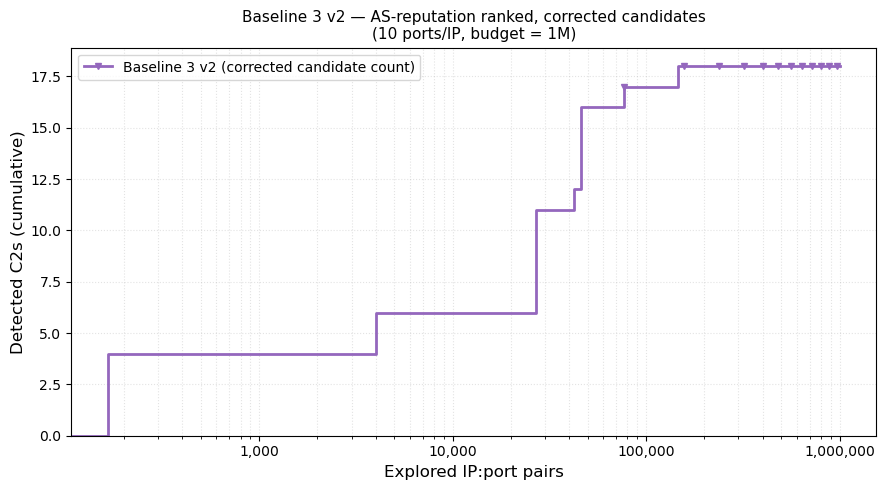

Saved: baseline3_v2.png  (baseline3.png from the uncorrected version above is untouched)
Saved Baseline_3_v2_corrected_candidates.csv  (262 points)


In [5]:
def run_baseline3_v2(seed_entries, all_segs, budget=MAX_BUDGET, verbose=True):
    """Same algorithm as Baseline 3 above (rank ASes by reputation, exhaustively
    probe each AS's candidate /24 segments in rank order) -- only the candidate
    segment universe (AS_TO_SEGS_V2) is corrected."""
    detected = set()
    oracle = Oracle()
    curve = []

    seg_counts = defaultdict(lambda: {'seeds': 0, 'live': 0})
    for row in seed_entries:
        seg = ip_to_subnet(row['ip'])
        seg_counts[seg]['seeds'] += 1
        if row['status'] == 'L':
            seg_counts[seg]['live'] += 1
    seed_cost = 0
    for seg, info in seg_counts.items():
        seed_cost += info['seeds'] * AVG_PORTS_PER_IP
        if info['live'] > 0:
            for ip in ground_truth_pool.get(seg, []):
                if any(s['ip'] == ip and s['status'] == 'L' for s in seed_entries):
                    detected.add(ip)
    curve.append((seed_cost, len(detected)))
    total_cost = seed_cost

    reputation = {asn: seeds_per_as.get(asn, 0) / len(segs)
                  for asn, segs in AS_TO_SEGS_V2.items() if segs}
    ranked = sorted(reputation, key=lambda a: (-reputation[a], a))
    if verbose:
        print(f"{'rank':<6}{'ASN':<12}{'seeds':>7}{'candidates':>12}{'reputation':>14}")
        for i, asn in enumerate(ranked, 1):
            print(f"{i:<6}{asn:<12}{seeds_per_as.get(asn,0):>7}{len(AS_TO_SEGS_V2[asn]):>12}{reputation[asn]:>14.6f}")

    all_segs_set = set(all_segs)
    ordered, seen = [], set()
    for asn in ranked:
        for seg in AS_TO_SEGS_V2[asn]:
            if seg in all_segs_set and seg not in seen:
                ordered.append(seg); seen.add(seg)
    for seg in all_segs:
        if seg not in seen:
            ordered.append(seg); seen.add(seg)

    for seg in ordered:
        if total_cost >= budget:
            break
        res = oracle.probe(seg)
        total_cost += res.cost
        detected.update(res.c2s_found)
        curve.append((total_cost, len(detected)))
    return curve, ranked, reputation


print('Running Baseline 3 v2 (corrected candidate count)...')
curve_b3_v2, ranked_v2, reputation_v2 = run_baseline3_v2(seeds, ALL_SEGMENTS_V2)
print(f'\n  -> {curve_b3_v2[-1][1]} C2s @ {curve_b3_v2[-1][0]:,} IP:ports')

xs = [0] + [c for c, _ in curve_b3_v2]
ys = [0] + [n for _, n in curve_b3_v2]
fig, ax = plt.subplots(figsize=(9, 5))
ax.step(xs, ys, where='post', color='#9467bd', lw=2, marker='v', ms=4,
        markevery=max(1, len(xs)//12), label='Baseline 3 v2 (corrected candidate count)')
ax.set_xlabel('Explored IP:port pairs', fontsize=12)
ax.set_ylabel('Detected C2s (cumulative)', fontsize=12)
ax.set_title('Baseline 3 v2 — AS-reputation ranked, corrected candidates\n(10 ports/IP, budget = 1M)', fontsize=11)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, which='both', ls=':', alpha=0.35)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('baseline3_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: baseline3_v2.png  (baseline3.png from the uncorrected version above is untouched)')

import csv
with open('Baseline_3_v2_corrected_candidates.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['cumulative_cost', 'cumulative_c2s'])
    w.writerows(curve_b3_v2)
print(f'Saved Baseline_3_v2_corrected_candidates.csv  ({len(curve_b3_v2)} points)')


### Combined Plot — All Five Methods (Baseline 3 v2)
Same as the "All Five Methods" combined plot above, with the corrected Baseline 3 substituted in.
Baseline 1, Baseline 2, and both BotScan variants are reloaded from the exact already-saved data
(`datapoints_table.csv` + the two `BotScan_*.csv` files) — unchanged from every earlier figure in
this notebook. Saved as a new file; nothing above is overwritten.

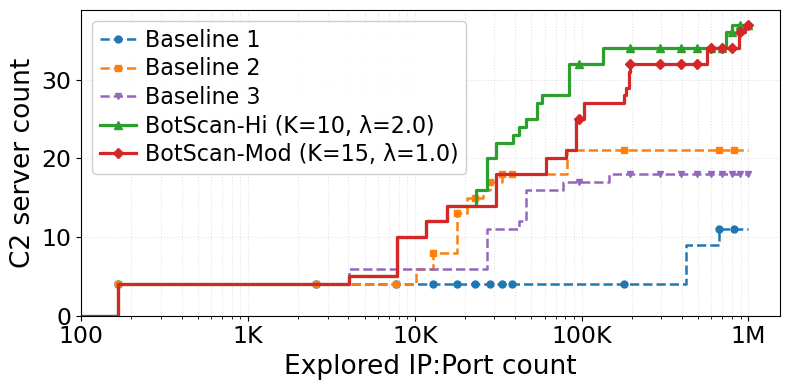

Saved: botscan_all_methods_with_baseline3_v2.png  (no earlier figure is overwritten)

Method                          Final C2s   Final cost
--------------------------------------------------------
Baseline 1                             11    1,000,000
Baseline 2                             21    1,000,000
Baseline 3                             18    1,002,405
BotScan-Hi (K=10, λ=2.0)               37    1,002,405
BotScan-Mod (K=15, λ=1.0)              37    1,002,405


In [6]:
# ── Combined plot: Baseline 1/2/BotScan reused verbatim, Baseline 3 = corrected version ──
import pandas as pd

_dp = pd.read_csv('datapoints_table.csv')

def _seed_phase_point():
    seg_counts = defaultdict(lambda: {'seeds': 0, 'live': 0})
    for row in seeds:
        seg = ip_to_subnet(row['ip'])
        seg_counts[seg]['seeds'] += 1
        if row['status'] == 'L':
            seg_counts[seg]['live'] += 1
    detected = set()
    seed_cost = 0
    for seg, info in seg_counts.items():
        seed_cost += info['seeds'] * AVG_PORTS_PER_IP
        if info['live'] > 0:
            for ip in ground_truth_pool.get(seg, []):
                if any(s['ip'] == ip and s['status'] == 'L' for s in seeds):
                    detected.add(ip)
    return seed_cost, len(detected)

_seed_cost, _seed_detected = _seed_phase_point()

def _checkpoint_curve(col):
    return [(0, 0), (_seed_cost, _seed_detected)] + list(zip(_dp['ip_port_budget'], _dp[col]))

def _load_curve_csv(fname):
    df = pd.read_csv(fname)
    return list(zip(df['cumulative_cost'], df['cumulative_c2s']))

curve_b1_saved   = _checkpoint_curve('Baseline_1')
curve_b2_saved   = _checkpoint_curve('Baseline_2')
curve_bsK3_saved = _load_curve_csv('BotScan_K3_lam10.csv')
curve_bsK1_saved = _load_curve_csv('BotScan_K1_lam20.csv')

all_curves_v3 = {
    'Baseline 1':                     (curve_b1_saved,   dict(color='#1f77b4', ls='--', lw=1.8, marker='o', ms=5)),
    'Baseline 2':                     (curve_b2_saved,   dict(color='#ff7f0e', ls='--', lw=1.8, marker='s', ms=5)),
    'Baseline 3':                     (curve_b3_v2,      dict(color='#9467bd', ls='--', lw=1.8, marker='v', ms=5)),
    'BotScan-Hi (K=10, \u03bb=2.0)':  (curve_bsK3_saved, dict(color='#2ca02c', ls='-',  lw=2.3, marker='^', ms=6)),
    'BotScan-Mod (K=15, \u03bb=1.0)': (curve_bsK1_saved, dict(color='#d62728', ls='-',  lw=2.3, marker='D', ms=5)),
}

fig, ax = plt.subplots(figsize=(8, 4))
for label, (c, style) in all_curves_v3.items():
    xs = [0] + [cost for cost, _ in c]
    ys = [0] + [n    for _, n    in c]
    ax.step(xs, ys, where='post', label=label,
            markevery=max(1, len(xs)//10), **style)

def fmt_k(x, pos):
    if x >= 1_000_000:
        v = x / 1_000_000
        return f'{v:.0f}M' if v == int(v) else f'{v:.1f}M'
    if x >= 1_000:
        v = x / 1_000
        return f'{v:.0f}K' if v == int(v) else f'{v:.1f}K'
    return f'{int(x)}'

ax.set_xlabel('Explored IP:Port count', fontsize=19)
ax.set_ylabel('C2 server count',        fontsize=19)
ax.tick_params(axis='both', labelsize=17)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(fmt_k))
ax.set_xticks([100, 1_000, 10_000, 100_000, 1_000_000])
ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
ax.legend(fontsize=16, loc='upper left', framealpha=0.95, labelspacing=0.25, handlelength=1.6, handletextpad=0.4, borderpad=0.35)
ax.grid(True, which='both', ls=':', alpha=0.35)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('botscan_all_methods_with_baseline3_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: botscan_all_methods_with_baseline3_v2.png  (no earlier figure is overwritten)')

print(f"\n{'Method':<30} {'Final C2s':>10} {'Final cost':>12}")
print('-' * 56)
for label, (c, _) in all_curves_v3.items():
    print(f"{label:<30} {c[-1][1]:>10} {c[-1][0]:>12,}")
